In [2]:


from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from glob import glob
import pandas as pd
from PIL import Image
import torchdata.datapipes as dp
import random
from torch.utils.data.backward_compatibility import worker_init_fn
from sklearn.metrics import classification_report
import wandb
import plotly.graph_objects as go
from pytorch_grad_cam import GradCAM

cudnn.benchmark = True
plt.ion()   # interactive mode


In [1]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve
import plotly.graph_objects as go
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

## Load Dataset

In [3]:
TRAIN_CSV_PATH = "/home/mahirwar/Desktop/Monika/npsad_data/monika/LBD/Intermediate_data/train_redmarked.csv"
VAL_CSV_PATH = "/home/mahirwar/Desktop/Monika/npsad_data/monika/LBD/Intermediate_data/val_redmarked.csv"

In [4]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df = pd.read_csv(VAL_CSV_PATH)

## Compute Mean and STD of the data

In [ ]:
psum    = torch.tensor([0.0, 0.0, 0.0])
psum_sq = torch.tensor([0.0, 0.0, 0.0])


# loop through images
for inputs in tqdm(train_loader):
    s = inputs[0].squeeze(0)
    psum    += s.sum(axis        = [0, 2, 3])
    psum_sq += (s ** 2).sum(axis = [0, 2, 3])

In [ ]:
# pixel count
image_size = 1024
count = dataset_sizes["train"] * image_size * image_size

# mean and std
total_mean = psum / count
total_var  = (psum_sq / count) - (total_mean ** 2)
total_std  = torch.sqrt(total_var)

# output
print('mean: '  + str(total_mean))
print('std:  '  + str(total_std))

## Build Torch Dataset

In [5]:
batch_size = 8

In [6]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(1024),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        #transforms.FiveCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
       # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        #transforms.Resize(256),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


In [7]:
def open_image(inputs):
    _ , wsi_name, img_path, label = inputs
    img = Image.open(img_path)
    return wsi_name, img, int(label)

def apply_train_transforms(inputs):
    _, x, y = inputs
    return data_transforms["train"](x), y

def apply_val_transforms(inputs):
    wsi_name, x, y = inputs
    return wsi_name, data_transforms["val"](x), y

def build_data_pipe(csv_file, transform , batch_size=32):
    new_dp = dp.iter.FileOpener([csv_file])
    new_dp = new_dp.parse_csv(skip_lines=1)
    # returns tuples like ('0','filename', 'filepath', 'label')
    if transform == "train":
        new_dp = new_dp.shuffle()
    
    new_dp = new_dp.sharding_filter()
    # important to use sharding_filter after (not before) shuffling -For the data source that needs to be sharded, it is crucial to add Shuffler before ShardingFilter to ensure data are globally shuffled before being split into shards. Otherwise, each worker process would always process the same shard of data for all epochs. And, it means each batch would only consist of data from the same shard, which leads to low accuracy during training. However, it doesn’t apply to the data source that has already been sharded for each multi-/distributed process, since ShardingFilter is no longer required to be presented in the pipeline.

    new_dp = new_dp.map(open_image)

    if transform == "train":
        new_dp = new_dp.map(apply_train_transforms)
        new_dp = new_dp.batch(batch_size=batch_size, drop_last=True)

    elif transform == "val":
        new_dp = new_dp.map(apply_val_transforms)
        new_dp = new_dp.batch(batch_size=batch_size, drop_last=False)

    else:
        raise ValueError("Invalid transform argument.")

    new_dp = new_dp.map(torch.utils.data.default_collate)
    return new_dp

def dataset_size(csv_file):
    df = pd.read_csv(csv_file)
    return len(df)


In [8]:
train_dp = build_data_pipe(TRAIN_CSV_PATH, "train", batch_size)
val_dp = build_data_pipe(VAL_CSV_PATH, "val", batch_size)

In [11]:
#train_dp = build_data_pipe("train1.csv", "train", batch_size)
#val_dp = build_data_pipe("val1.csv", "val", batch_size)

In [9]:

train_datasize = dataset_size(TRAIN_CSV_PATH)
val_datasize = dataset_size(VAL_CSV_PATH)
dataset_sizes = {'train':train_datasize, 'val':val_datasize}

In [10]:
dataset_sizes

{'train': 172789, 'val': 76791}

In [11]:
train_loader = torch.utils.data.DataLoader(
    dataset=train_dp, shuffle=True, num_workers=4)

val_loader = torch.utils.data.DataLoader(
    dataset=val_dp, shuffle=False, num_workers=4)

dataloaders = {"train":train_loader, "val": val_loader}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

data_dir =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/"
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          transform = data_transforms['train'])
                  for x in ['11_063_CG_aSyn_x200.svs']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['11_063_CG_aSyn_x200.svs']}

torch.Size([16, 3, 1024, 1024])
tensor([[0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 2]])
torch.Size([3, 2054, 8210])
torch.Size([3, 2054, 8210])
(2054, 8210, 3)


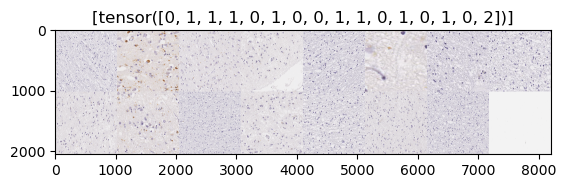

In [13]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.squeeze()
    print(inp.shape)
    #inp = inp.numpy().transpose((0, 3, 2, 1))
    inp = inp.numpy().transpose((1, 2, 0))
    
    print(inp.shape)
    mean = np.array([0.8965, 0.8875, 0.9023])
    std = np.array([0.0807, 0.0911, 0.0849])
    #mean = np.array([0.485, 0.456, 0.406])
    #std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated



def tensor_2_img(inp):
    """Imshow for Tensor."""
    inp = inp.squeeze(0)
    print(inp.shape)
    #inp = inp.numpy().transpose((0, 3, 2, 1))
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    
    print(inp.shape)
    mean = np.array([0.8965, 0.8875, 0.9023])
    std = np.array([0.0807, 0.0911, 0.0849])
    #mean = np.array([0.485, 0.456, 0.406])
    #std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    return Image.fromarray((inp).astype(np.uint8))




# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))
inputs = inputs.squeeze()
print(inputs.shape)
print(classes)

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)
print(out.shape)
imshow(out, title=[x for x in classes])

## Train Model

In [12]:
train_config = dict(
    epochs = 20,
    batch_size = batch_size,
    num_classes = 3,
    device_id = 0,
    eval_freq = 1,
)

In [13]:

test_config = dict(
    batch_size = 32
)

model_config = dict(lr=0.001, momentum=0.9)

optim_config = dict(step_size=7, gamma=0.1)


wandb_config = dict(
    project='LBD',
    entity='monika-ahirwar',
    config=dict(
        train_config=train_config,
        model_config=model_config,
        optim_config=optim_config,
    ),
    save_code=False,
    group='runs',
    job_type='train',
)
run = wandb.init(**wandb_config)
assert run is wandb.run # run was successfully initialized, is not None
run_id, run_dir = run.id, run.dir
exp_name = run.name
artifact_name = f'{run_id}-logs'

WANDB_NOTEBOOK_NAME = "WM_Classification_RedMarked.ipynb"


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: monika-ahirwar. Use `wandb login --relogin` to force relogin


In [14]:
def plot_roc_auc_curve(run, actual_labels, y_scores, classes, wsi_name):
    y_onehot = pd.get_dummies(actual_labels, columns=classes)
    y_scores = pd.DataFrame(y_scores)
    for i, c in enumerate(classes):
        y_scores[c]=y_scores["scores"].apply(lambda l: l[i])
    y_scores.drop(["scores"], axis=1,inplace=True)
    
    table = wandb.Table(columns = [wsi_name])
    fig = go.Figure()
    fig.add_shape(
        type='line', line=dict(dash='dash'),
        x0=0, x1=1, y0=0, y1=1
    )

    for i in range(len(classes)):
        y_true = y_onehot.iloc[:, i]
        y_score = y_scores.iloc[:, i]

        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc_score = roc_auc_score(y_true, y_score)

        name = f"{y_onehot.columns[i]} (AUC={auc_score:.2f})"
        fig.add_trace(go.Scatter(x=fpr, y=tpr, name=name, mode='lines'))

    fig.update_layout(
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        yaxis=dict(scaleanchor="x", scaleratio=1),
        xaxis=dict(constrain='domain'),
        width=700, height=500
    )
    fig.write_html(os.path.join(eval_path, "ROC_Curve" + wsi_name +".html"), auto_play = False)
    table.add_data(wandb.Html(os.path.join(eval_path, "ROC_Curve" + wsi_name +".html")))
    run.log({"ROC Curve": table})



def plot_pr_curve(run, actual_labels, y_scores, classes, wsi_name):
    table = wandb.Table(columns = [wsi_name])
    y_onehot = pd.get_dummies(actual_labels, columns=classes)
    y_scores = pd.DataFrame(y_scores)
    for i, c in enumerate(classes):
        y_scores[c]=y_scores["scores"].apply(lambda l: l[i])
    y_scores.drop(["scores"], axis=1,inplace=True)
    
    fig = go.Figure()
    for i in range(len(classes)):
        y_true = y_onehot.iloc[:, i]
        y_score = y_scores.iloc[:, i]
        precision, recall, thresholds = precision_recall_curve(y_true, y_score)
        fig.add_trace(go.Scatter(x=recall, y=precision, name=classes[i], mode='lines'))

    fig.update_layout(
        xaxis_title='Recall',
        yaxis_title='Precision',
        yaxis=dict(scaleanchor="x", scaleratio=1),
        xaxis=dict(constrain='domain'),
        width=700, height=500
    )

    fig.write_html(os.path.join(eval_path, "PR_Curve" + wsi_name +".html"), auto_play = False)
    table.add_data(wandb.Html(os.path.join(eval_path, "PR_Curve" + wsi_name +".html")))
    run.log({"PR Curve": table})



def plot_training_curve(log_metrics):
    # Create traces
    log_metrics = pd.DataFrame(log_metrics)
    for c in ["loss", "metrics"]:
        fig = go.Figure()
        if c=="loss":
            fig.add_trace(go.Scatter(x=log_metrics[log_metrics["phase"]=="train"]["epoch"], y=log_metrics[log_metrics["phase"]=="train"][c],
                                mode='lines+markers',
                                name='Training loss'))
            #fig.add_trace(go.Scatter(x=log_metrics[log_metrics["phase"]=="val"]["epoch"], y=log_metrics[log_metrics["phase"]=="val"][c],
            #                    mode='lines+markers',
            #                    name='Validation loss'))

            fig.update_layout(title='Training/Validation loss vs Epoch',
                            xaxis_title='Epoch No',
                            yaxis_title='Loss')

            fig.write_html(eval_path + "Training_loss_curve.html")
            table = wandb.Html(eval_path + "Training_loss_curve.html")
            wandb.log({"Training Loss":table})
        else:
            fig.add_trace(go.Scatter(x=log_metrics[log_metrics["phase"]=="train"]["epoch"], y=log_metrics[log_metrics["phase"]=="train"][c],
                                mode='lines+markers',
                                name='Training Accuracy'))
            #fig.add_trace(go.Scatter(x=log_metrics[log_metrics["phase"]=="val"]["epoch"], y=log_metrics[log_metrics["phase"]=="val"][c],
            #                    mode='lines+markers',
            #                    name='Validation Accuracy'))           

            fig.update_layout(title='Training/Validation Acccuracy vs Epoch',
                            xaxis_title='Epoch No',
                            yaxis_title='Accuracy')

            fig.write_html(eval_path + "Training_Accuracy_curve.html")
            table = wandb.Html(eval_path + "Training_Accuracy_curve.html")
            wandb.log({"Training Accuracy":table})

In [15]:
def val_model(model,criterion):
    model.eval()
    running_corrects = 0
    running_loss = 0.0
    with torch.no_grad():
        for i, (wsi, inputs, labels) in enumerate(dataloaders['val']):
            #print("-------------------",i,"--------------------")
            inputs = inputs.squeeze(0)
            labels = labels.squeeze(0)
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
    epoch_acc = running_corrects/dataset_sizes['val']
    epoch_loss = running_loss/dataset_sizes['val']
    return epoch_acc, epoch_loss
            


def train_model(run, model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    log_metrics = list()
    phase = 'train'
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)
        # Each epoch has a training and validation phase
        phase = 'train'
        model.train()  # Set model to training mode
        running_loss = 0.0
        running_corrects = 0
        for i, (inputs, labels) in enumerate(dataloaders[phase]):
            inputs=inputs.squeeze(0)
            labels = labels.squeeze(0)
            inputs = inputs.to(device)
            labels = labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            #print(f'Epoch {epoch} {phase} Loss: {loss.item():.4f} Batch No: {i}') 
        scheduler.step()
        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        #try:
        val_acc, val_loss = val_model(model,criterion)
        print(f'Epoch {epoch} {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Val_Acc: {val_acc:.4f} Val_Loss: {val_loss:.4f}')
        log_metrics.append(dict(epoch=epoch, loss=epoch_loss, metrics=epoch_acc,val_loss=val_loss, val_metrics=val_acc))
        if epoch==5:
            torch.save({"model":model, "state": model.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/'+run_id+'5.pth')
        if epoch==10:
            torch.save({"model":model, "state": model.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/'+run_id+'10.pth')
        if epoch==15:
            torch.save({"model":model, "state": model.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/'+run_id+'15.pth')
        
        #except Exception as e: 
        #    print(e)
        #    print(f'Epoch {epoch} {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        #    log_metrics.append(dict(epoch=epoch, loss=epoch_loss, metrics=epoch_acc))
            
        #print(f'Epoch {epoch} {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        #log_metrics.append(dict(epoch=epoch, loss=epoch_loss, metrics=epoch_acc,val_loss=val_loss, val_metrics=val_acc))
        #log_metrics.append(dict(epoch=epoch, loss=epoch_loss, metrics=epoch_acc))
        
    run.log({"log":log_metrics})
    artifact = wandb.Artifact(artifact_name, type='files')
    with artifact.new_file(f'ckpt/{epoch}.pt', 'wb') as f:
        torch.save(model.state_dict(), f)
    torch.save({"model":model, "state": model.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/'+artifact_name+'.pth')
    run.log_artifact(artifact)
    #run.finish()
    return model, log_metrics

def load_saved_model(path):
    checkpoint = torch.load(path)
    model_ft = checkpoint["model"]
    model_ft.load_state_dict(checkpoint['state'])
    return model_ft

In [16]:
def test_model(model, run):
    was_training = model.training
    model.eval()
    actual_labels = []
    pred_labels = []
    wsi_names = []
    scores=[]
    with torch.no_grad():
        for i, (wsi, inputs, labels) in enumerate(dataloaders['val']):
            #print("-------------------",i,"--------------------")
            inputs=inputs.squeeze()
            labels = labels.squeeze()
            inputs = inputs.to(device)
            labels = labels.to(device)
            actual_labels.extend(labels.tolist())
            outputs = model(inputs)
            scores.extend(outputs.cpu().tolist())
            _, preds = torch.max(outputs, 1)
            #print(preds)
            pred_labels.extend(preds.tolist())
            #print(wsi)
            wsi=[x[0] for x in wsi]
            wsi_names.extend(wsi)
            if i%500==0:
                print(i, "Done")
            #if (i!=0) and (i%1000==0):
            #    break
        
    output_df = pd.DataFrame({"wsi_name":wsi_names,"actual_labels":actual_labels,"pred_labels":pred_labels,"scores":scores})

    classes = [0,1,2]
    try:
        plot_roc_auc_curve(run, actual_labels, scores, classes)
    except:
        pass

    eval_metrics = pd.DataFrame(columns=["WSI","accu_score","precision-white","recall-white","f1-score-white","support-white", "precision-grey","recall-grey","f1-score-grey","support-grey", "precision-bg","recall-bg","f1-score-bg","support-bg"])
    ind =0 
    for wsi in output_df['wsi_name'].unique():
        tmp = output_df[output_df["wsi_name"]==wsi]  
        acc_score = accuracy_score(tmp["actual_labels"], tmp["pred_labels"])
        prec_rec = precision_recall_fscore_support(tmp["actual_labels"], tmp["pred_labels"], labels=[0,1,2])
        #avg_acc.append(acc_score)
        #print("-----Evaluation Metric for WSI-------",wsi )
        #print(acc_score)
        #print(prec_rec)
        eval_metrics.loc[ind] = (wsi, acc_score, prec_rec[0][0],prec_rec[1][0],prec_rec[2][0],prec_rec[3][0], prec_rec[0][1],prec_rec[1][1],prec_rec[2][1],prec_rec[3][1], prec_rec[0][2],prec_rec[1][2],prec_rec[2][2],prec_rec[3][2] )
        ind=ind+1
        wandb.summary["Evaluation Metric for WSI :" + wsi]=acc_score
    tbl = wandb.Table(data=eval_metrics)
    run.log({"Test Evaluation Metric": tbl})
    eval_metrics.to_csv(eval_path + "eval_metric.csv")
    print(eval_metrics)
    conf_matrix = confusion_matrix(output_df["actual_labels"],output_df["pred_labels"])
    print(conf_matrix)
    try:
        wandb.log({"conf_mat" : wandb.plot.confusion_matrix(probs=None,
                        y_true=output_df["actual_labels"].values, preds=output_df["pred_labels"].values,
                        class_names=["White","gray","background"])})
    except:
        pass

    return output_df

In [17]:
def visualize_model(model, num_images=20):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            print(labels)
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


In [18]:
model_ft = models.resnet50(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, train_config["num_classes"])

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
#optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.00001, weight_decay=1e-5)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [23]:
#path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/20xm0ww6-logs.pth'
#path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/w97ipitr-logs.pth'
#path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/221kusfe-logs.pth'

#model_ft = load_saved_model(path)
#model_ft = model_ft.to(device)

In [24]:
""" 
cam = GradCAM(model=model_ft, target_layers=target_layers, use_cuda=True)
first_train_batch = next(iter(train_loader))
input_tensor = first_train_batch[0].squeeze().to(device)
input_tensor[0].unsqueeze(0).shape
rgb_img = tensor_2_img(input_tensor[0])
grayscale_cam = cam(input_tensor=input_tensor[0].unsqueeze(0))
# In this example grayscale_cam has only one image in the batch:
grayscale_cam = grayscale_cam[0, :]
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

Image.fromarray(visualization, 'RGB')
"""

" \ncam = GradCAM(model=model_ft, target_layers=target_layers, use_cuda=True)\nfirst_train_batch = next(iter(train_loader))\ninput_tensor = first_train_batch[0].squeeze().to(device)\ninput_tensor[0].unsqueeze(0).shape\nrgb_img = tensor_2_img(input_tensor[0])\ngrayscale_cam = cam(input_tensor=input_tensor[0].unsqueeze(0))\n# In this example grayscale_cam has only one image in the batch:\ngrayscale_cam = grayscale_cam[0, :]\nvisualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)\n\nImage.fromarray(visualization, 'RGB')\n"

In [19]:
#start = torch.cuda.Event(enable_timing=True)
model_ft, log_metrics = train_model(run, model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=train_config["epochs"])
#end = torch.cuda.Event(enable_timing=True)
#torch.cuda.synchronize()

#print(start.elapsed_time(end))

Epoch 0/19
----------


In [ ]:
/home/mahirwar/Projects/XMem/saves/Aug29_16.33.12_retrain-s0-a6000_s3/Aug29_16.33.12_retrain-s0-a6000_s3_10010.pth

In [24]:
torch.cuda.empty_cache()

In [20]:
plot_training_curve(log_metrics)

NameError: name 'eval_path' is not defined

## Test Model

In [19]:
eval_path = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_Evaluation_Metrics/"+run_id

if not os.path.exists(eval_path):
    os.makedirs(eval_path)

In [20]:
#torch.save({"model":model_ft, "state": model_ft.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/model_4_dlb_4_pdd.pth')

def load_saved_model(path):
    checkpoint = torch.load(path)
    model_ft = checkpoint["model"]
    model_ft.load_state_dict(checkpoint['state'])
    return model_ft

In [21]:
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/3kzmfag1-logs.pth'
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/20xm0ww6-logs.pth'
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/221kusfe-logs.pth'
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/i43d6xcy10.pth'

In [48]:
#torch.save({"model":model_ft, "state": model_ft.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/2nqho457-logs2.pth')

In [22]:
model_ft = load_saved_model(path)

In [23]:
output_df = test_model(model_ft, run)

0 Done
500 Done
1000 Done
1500 Done
2000 Done
2500 Done
3000 Done
3500 Done
4000 Done
4500 Done
                                                  WSI  accu_score  \
0   /gladstone/finkbeiner/steve/work/data/npsad_da...    0.989996   
1   /gladstone/finkbeiner/steve/work/data/npsad_da...    0.996846   
2   /gladstone/finkbeiner/steve/work/data/npsad_da...    0.963854   
3   /gladstone/finkbeiner/steve/work/data/npsad_da...    0.998478   
4   /gladstone/finkbeiner/steve/work/data/npsad_da...    0.995199   
5   /gladstone/finkbeiner/steve/work/data/npsad_da...    0.980392   
6   /gladstone/finkbeiner/steve/work/data/npsad_da...    1.000000   
7   /gladstone/finkbeiner/steve/work/data/npsad_da...    0.993270   
8   /gladstone/finkbeiner/steve/work/data/npsad_da...    0.996820   
9   /gladstone/finkbeiner/steve/work/data/npsad_da...    0.996378   
10  /gladstone/finkbeiner/steve/work/data/npsad_da...    0.618881   

    precision-white  recall-white  f1-score-white  support-white  \
0      

In [24]:
output_df

,wsi_name,actual_labels,pred_labels,scores
0,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,0,"[10.305566787719727, -5.645960330963135, -20.8..."
1,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,0,"[10.491771697998047, -6.002834320068359, -19.7..."
2,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,0,"[6.9532670974731445, -4.072116374969482, -12.3..."
3,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,0,"[10.083964347839355, -6.693228244781494, -17.2..."
4,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,0,"[7.411574840545654, -5.386409282684326, -11.09..."
...,...,...,...,...
76786,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,0,"[0.6109408140182495, -1.4284719228744507, -0.2..."
76787,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,0,"[0.8600988984107971, -1.8284844160079956, -0.1..."
76788,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,2,"[-0.20724250376224518, -0.9781081676483154, -0..."
76789,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,0,"[0.5816293358802795, -1.3314239978790283, -0.2..."


In [26]:
output_df[output_df["actual_labels"]!=output_df["pred_labels"]]

,wsi_name,actual_labels,pred_labels,scores
16,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,1,"[1.8081246614456177, 2.16890549659729, -10.533..."
145,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,1,"[2.565758228302002, 2.7569637298583984, -13.45..."
324,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,1,"[2.179320812225342, 2.437615156173706, -11.622..."
338,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,1,"[1.506786823272705, 2.9268341064453125, -11.03..."
381,/gladstone/finkbeiner/steve/work/data/npsad_da...,0,1,"[1.373026728630066, 3.259953260421753, -11.366..."
...,...,...,...,...
76785,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,0,"[0.6985715627670288, -1.3858332633972168, -0.4..."
76786,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,0,"[0.6109408140182495, -1.4284719228744507, -0.2..."
76787,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,0,"[0.8600988984107971, -1.8284844160079956, -0.1..."
76789,/gladstone/finkbeiner/steve/work/data/npsad_da...,2,0,"[0.5816293358802795, -1.3314239978790283, -0.2..."


: 

## Model Analysis

In [19]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.squeeze()
    print(inp.shape)
    #inp = inp.numpy().transpose((0, 3, 2, 1))
    inp = inp.numpy().transpose((1, 2, 0))
    
    print(inp.shape)
    mean = np.array([0.8965, 0.8875, 0.9023])
    std = np.array([0.0807, 0.0911, 0.0849])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

In [21]:
def save_image(input_tensor, path, name):
    inp = input_tensor.squeeze(0)
    print(inp.shape)
    #inp = inp.numpy().transpose((0, 3, 2, 1))
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    print(inp.shape)
    mean = np.array([0.8965, 0.8875, 0.9023])
    std = np.array([0.0807, 0.0911, 0.0849])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    img = Image.fromarray((inp* 255).astype(np.uint8))
    img.save(os.path.join(path, name + ".png"))

def visualize_model(model, num_images=0):
    was_training = model.training
    #model.eval()
    images_so_far = 0
    fig = plt.figure()
    model.eval()
    actual_labels = []
    pred_labels = []
    wsi_names = []
    scores=[]
    act_white_labeled_gray = []
    act_gray_labeled_white = []
    c1=0
    c2=0
    #with torch.no_grad():
    target_layers = [model.layer4[-1]]
    for i, (wsi, inputs, labels) in enumerate(dataloaders['val']):
        #print("-------------------",i,"--------------------")
        inputs=inputs.squeeze()
        labels = labels.squeeze()
        inputs = inputs.to(device)
        labels = labels.to(device)
        actual_labels = labels.tolist()
        #actual_labels.extend(labels.tolist())
        outputs = model(inputs)
        scores.extend(outputs.cpu().tolist())
        _, preds = torch.max(outputs, 1)
        pred_labels = preds.tolist()
        #print(preds)
        #pred_labels.extend(preds.tolist())
        #print(wsi)
        wsi=[x[0] for x in wsi]
        #wsi_names.extend(wsi)
        for j in range(len(labels)):
            if c1>=5:
                break
            if (actual_labels[j]==0) and (pred_labels[j]==1):
                save_image(inputs[j],"/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/w_act_pred_gray", wsi[0]+"_"+str(i)+"_"+str(j))
                c1=c1+1
            
                    
            """
            if (actual_labels[j]==1) and (pred_labels[j]==0):
                print("Actual: Gray, Predicted: White ")
            #   save_image(inputs[j],"/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/w_act_pred_gray",i+"_"+j)
                imshow(inputs.cpu().data[j])
                input_tensor=inputs[j].unsqueeze(0)
                grayscale_cam = cam(input_tensor)
                grayscale_cam = grayscale_cam[0, :]
                rgb_img = tensor_2_img(input_tensor[0])
                visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)     
                plt.imshow(Image.fromarray(visualization, 'RGB'))    
                c2=c2+1
            """
        #act_gray_labeled_white.extend(unmatched)
        #if (i%5000==0) & (i!=0):
        #    break
    return c1, c2


In [24]:
                print("Actual: White, Predicted: Gray ")
                imshow(inputs.cpu().data[j])
                print(inputs[j].unsqueeze(0).shape)
                input_tensor=inputs[j].unsqueeze(0)
                cam = GradCAM(model=model, target_layers=target_layers, use_cuda=True)
                grayscale_cam = cam(input_tensor=input_tensor)
                grayscale_cam = grayscale_cam[0, :]
                rgb_img = tensor_2_img(input_tensor[0])
                visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)     
                plt.imshow(Image.fromarray(visualization, 'RGB'))    

Actual: White, Predicted: Gray 


NameError: name 'j' is not defined

In [31]:
inputs = next(iter(dataloaders['train']))


In [33]:
inputs[0].shape

torch.Size([1, 16, 3, 1024, 1024])

In [34]:
input_tensor = inputs[0].squeeze()[0].unsqueeze(0)

In [35]:
input_tensor.shape

torch.Size([1, 3, 1024, 1024])

In [37]:
save_image(input_tensor,"/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/w_act_pred_gray","temp"+str(0)+"_"+str(0))

torch.Size([3, 1024, 1024])
(1024, 1024, 3)


: 

In [ ]:
            #    save_image(inputs[j],"/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/w_act_pred_gray",i+"_"+j)
                print("Actual: White, Predicted: Gray ")
                imshow(inputs.cpu().data[j])
                print(inputs[j].unsqueeze(0).shape)
                input_tensor=inputs[j].unsqueeze(0)
                cam = GradCAM(model=model, target_layers=target_layers, use_cuda=True)
                grayscale_cam = cam(input_tensor=input_tensor)
                grayscale_cam = grayscale_cam[0, :]
                rgb_img = tensor_2_img(input_tensor[0])
                visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)     
                plt.imshow(Image.fromarray(visualization, 'RGB'))    
                c1=c1+1
            """
            if (actual_labels[j]==1) and (pred_labels[j]==0):
                print("Actual: Gray, Predicted: White ")
            #   save_image(inputs[j],"/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/w_act_pred_gray",i+"_"+j)
                imshow(inputs.cpu().data[j])
                input_tensor=inputs[j].unsqueeze(0)
                grayscale_cam = cam(input_tensor)
                grayscale_cam = grayscale_cam[0, :]
                rgb_img = tensor_2_img(input_tensor[0])
                visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)     
                plt.imshow(Image.fromarray(visualization, 'RGB'))    
                c2=c2+1
            """
            if c1==5:
                break
        #act_gray_labeled_white.extend(unmatched)
        #if (i%5000==0) & (i!=0):
        #    break

In [22]:
act_white_labeled_gray, act_gray_labeled_white = visualize_model(model_ft, num_images=0)

torch.Size([3, 1024, 1024])
(1024, 1024, 3)
torch.Size([3, 1024, 1024])
(1024, 1024, 3)
torch.Size([3, 1024, 1024])
(1024, 1024, 3)
torch.Size([3, 1024, 1024])
(1024, 1024, 3)
torch.Size([3, 1024, 1024])
(1024, 1024, 3)


<Figure size 640x480 with 0 Axes>

In [ ]:
act_gray_labeled_white

8

In [54]:
act_white_labeled_gray

8

In [21]:
for i, (wsi, inputs, labels) in enumerate(dataloaders['val']):
    inputs=inputs.squeeze()
    for j in range(inputs.shape[0]):
        save_image(inputs[j],"/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_misclassification/w_act_pred_gray",i+"_"+j)
        break
    break
        

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [31]:
inputs[j].cpu().detach().numpy()[0].shape

(1024, 1024)

torch.Size([3, 1024, 1024])
(1024, 1024, 3)


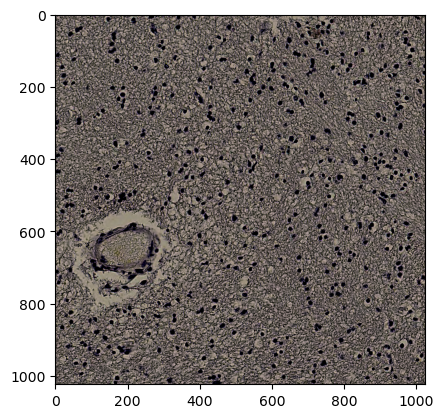

In [33]:
imshow(inputs.cpu().data[j])

In [27]:
img = Image.fromarray(inputs[j].cpu().detach().numpy()[0])

TypeError: Cannot handle this data type: (1, 1, 1024), <f4